In [6]:
# Imports, loading and checking the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('medical_cost_with_additional_missing_values.csv')
print(df.head())
print(f"Shape: {df.shape}")
print(f"Features: {len(df.columns)}")
#print(f"Classes of Purchase_Made(target variable): {df['Purchase_Made'].unique()}")
print(f"Missing Values Before Cleaning: {df.isnull().sum()}")


   age  gender   bmi smoker  diabetes  hypertension  heart_disease  asthma  \
0   69    Male  29.4     No         1             0              0       0   
1   32  Female  22.9     No         1             0              0       0   
2   89    Male  25.7     No         0             0              0       0   
3   78    Male  31.9    Yes         0             1              0       0   
4   38    Male  27.7     No         0             0              0       0   

  physical_activity_level  daily_steps  sleep_hours  stress_level  \
0                  Medium        14825          4.4             8   
1                  Medium         3620          6.0             7   
2                    High        10578          4.5             7   
3                     Low         6226          8.6             9   
4                    High         6253          5.7             3   

   doctor_visits_per_year  hospital_admissions  medication_count  \
0                       1                  NaN  

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)

# raw load – use the exact filename in your Files pane
df_raw = pd.read_csv('medical_cost_with_additional_missing_values.csv')

df_raw.head()


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,NaN,4.0,Private,80.0,Semi-Urban,10885.0,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3.0,0.0,Government,64.0,Semi-Urban,18722.0,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,NaN,3.0,NaN,0.0,Urban,NaN,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,NaN,NaN,Government,70.0,Urban,11128.0,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0.0,NaN,Private,77.0,Urban,15110.0,3202.52


In [9]:
df_raw.info()
df_raw.isna().sum()
print("Shape (rows, cols):", df_raw.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   object 
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      4000 non-null   float64
 14  medication_count        

In [10]:
target_col = 'annual_medical_cost'   # adjust if needed

X = df_raw.drop(columns=[target_col])
y = df_raw[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (3500, 19)
Test shape: (1500, 19)


In [11]:
X_train.describe()


,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.00000,3500.000000,3500.000000,3500.000000,2797.000000,2794.000000,3500.000000,2816.000000
mean,53.222571,26.003743,0.209143,0.287143,0.144286,0.099143,8067.98200,6.488000,5.475429,4.039714,0.988917,3.515748,57.969143,10264.061080
std,20.662862,5.070158,0.406755,0.452493,0.351429,0.298896,4054.03339,1.438931,2.916328,2.007665,0.970719,2.305041,31.580609,5614.034366
min,18.000000,6.800000,0.000000,0.000000,0.000000,0.000000,1004.00000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,500.000000
25%,36.000000,22.700000,0.000000,0.000000,0.000000,0.000000,4622.50000,5.200000,3.000000,3.000000,0.000000,1.000000,53.000000,5379.250000
50%,53.000000,26.000000,0.000000,0.000000,0.000000,0.000000,8138.50000,6.500000,5.000000,4.000000,1.000000,3.000000,71.000000,10258.000000
75%,71.000000,29.400000,0.000000,1.000000,0.000000,0.000000,11597.00000,7.700000,8.000000,5.000000,2.000000,6.000000,79.000000,14977.500000
max,89.000000,43.600000,1.000000,1.000000,1.000000,1.000000,14999.00000,9.000000,10.000000,14.000000,6.000000,7.000000,94.000000,19996.000000


In [12]:
X_train.isna().sum()


,0
age,0
gender,0
bmi,0
smoker,0
diabetes,0
hypertension,0
heart_disease,0
asthma,0
physical_activity_level,0
daily_steps,0


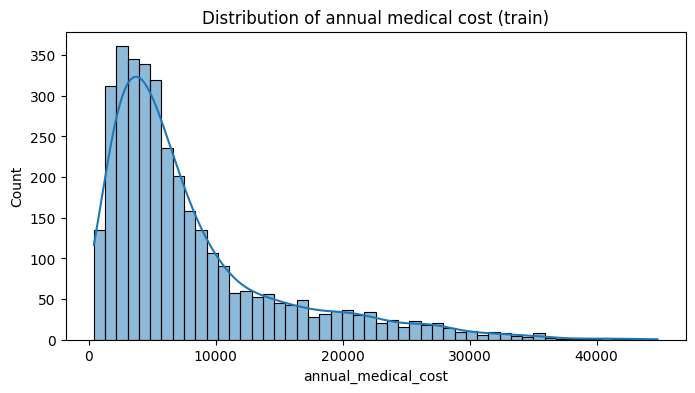

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(y_train, kde=True)
plt.title("Distribution of annual medical cost (train)")
plt.show()


In [14]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", cat_cols.tolist())
print("Numeric:", num_cols.tolist())


Categorical: ['gender', 'smoker', 'physical_activity_level', 'insurance_type', 'city_type']
Numeric: ['age', 'bmi', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost']


In [15]:
# copy to avoid modifying X_train directly
X_train_clean = X_train.copy()

# numeric: fill with median
for col in num_cols:
    X_train_clean[col] = X_train_clean[col].fillna(X_train_clean[col].median())

# categorical: fill with mode (most frequent)
for col in cat_cols:
    X_train_clean[col] = X_train_clean[col].fillna(X_train_clean[col].mode()[0])

X_train_clean.isna().sum()


,0
age,0
gender,0
bmi,0
smoker,0
diabetes,0
hypertension,0
heart_disease,0
asthma,0
physical_activity_level,0
daily_steps,0


In [16]:
X_train_fe = X_train_clean.copy()

# Example: BMI * smoker flag (if you have 'bmi' and 'smoker' columns)
if 'bmi' in X_train_fe.columns and 'smoker' in X_train_fe.columns:
    X_train_fe['bmi_smoker_interaction'] = (
        X_train_fe['bmi'] * (X_train_fe['smoker'] == 'yes').astype(int)
    )

# Example: age group buckets
if 'age' in X_train_fe.columns:
    X_train_fe['age_group'] = pd.cut(
        X_train_fe['age'],
        bins=[0, 25, 40, 60, np.inf],
        labels=['young', 'adult', 'middle_aged', 'senior']
    )

X_train_fe.head()


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,bmi_smoker_interaction,age_group
1840,20,Male,33.2,Yes,0,1,0,0,Low,13589,8.8,6,6,1.0,3.0,Private,74.0,Urban,5423.0,0.0,young
2115,30,Male,34.4,No,0,1,0,0,Low,8698,5.9,1,1,0.0,3.0,Government,63.0,Rural,14948.0,0.0,adult
4437,32,Male,19.9,No,0,0,0,0,Low,6563,5.8,4,2,1.0,4.0,Government,0.0,Urban,10258.0,0.0,adult
1146,64,Female,24.6,No,0,0,0,0,High,11580,6.6,5,1,1.0,5.0,Government,0.0,Semi-Urban,13533.0,0.0,senior
2486,38,Male,32.6,No,0,0,0,1,Low,4264,5.1,7,5,0.0,5.0,Government,60.0,Urban,2158.0,0.0,adult


In [17]:
cat_cols = X_train_fe.select_dtypes(include=['object', 'category']).columns
num_cols = X_train_fe.select_dtypes(include=['int64', 'float64']).columns
print("Updated categorical:", cat_cols.tolist())
print("Updated numeric:", num_cols.tolist())


Updated categorical: ['gender', 'smoker', 'physical_activity_level', 'insurance_type', 'city_type', 'age_group']
Updated numeric: ['age', 'bmi', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost', 'bmi_smoker_interaction']


In [18]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # scaling / normalization
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


In [19]:
# fit only on train
X_train_prepared = preprocessor.fit_transform(X_train_fe)

# apply to test (first create test version with same engineering)
X_test_clean = X_test.copy()

for col in num_cols:
    if col in X_test_clean.columns:
        X_test_clean[col] = X_test_clean[col].fillna(X_train_clean[col].median())

for col in cat_cols:
    if col in X_test_clean.columns:
        X_test_clean[col] = X_test_clean[col].fillna(X_train_clean[col].mode()[0])

X_test_fe = X_test_clean.copy()

if 'bmi' in X_test_fe.columns and 'smoker' in X_test_fe.columns:
    X_test_fe['bmi_smoker_interaction'] = (
        X_test_fe['bmi'] * (X_test_fe['smoker'] == 'yes').astype(int)
    )

if 'age' in X_test_fe.columns:
    X_test_fe['age_group'] = pd.cut(
        X_test_fe['age'],
        bins=[0, 25, 40, 60, np.inf],
        labels=['young', 'adult', 'middle_aged', 'senior']
    )

X_test_prepared = preprocessor.transform(X_test_fe)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape:", X_test_prepared.shape)


Prepared train shape: (3500, 31)
Prepared test shape: (1500, 31)


In [20]:
print("=== RAW DATA (train) ===")
print(X_train.head())
print(X_train.isna().sum())


=== RAW DATA (train) ===
      age  gender   bmi smoker  diabetes  hypertension  heart_disease  asthma  \
1840   20    Male  33.2    Yes         0             1              0       0   
2115   30    Male  34.4     No         0             1              0       0   
4437   32    Male  19.9     No         0             0              0       0   
1146   64  Female  24.6     No         0             0              0       0   
2486   38    Male  32.6     No         0             0              0       1   

     physical_activity_level  daily_steps  sleep_hours  stress_level  \
1840                     Low        13589          8.8             6   
2115                     Low         8698          5.9             1   
4437                     Low         6563          5.8             4   
1146                    High        11580          6.6             5   
2486                     Low         4264          5.1             7   

      doctor_visits_per_year  hospital_admissions  medi

In [21]:
# get column names from transformer
ohe = preprocessor.named_transformers_['cat']['onehot']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = list(num_cols) + list(cat_feature_names)

df_train_final = pd.DataFrame(X_train_prepared, columns=all_feature_names)
df_train_final.head()


,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,bmi_smoker_interaction,gender_Female,gender_Male,smoker_No,smoker_Yes,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Medium,insurance_type_Government,insurance_type_Private,city_type_Rural,city_type_Semi-Urban,city_type_Urban,age_group_adult,age_group_middle_aged,age_group_senior,age_group_young
0,-1.608069,1.419539,-0.514248,1.575623,-0.410627,-0.331744,1.362053,1.606978,0.179900,0.976540,0.010208,-0.198945,0.507690,-0.961289,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.124040,1.656251,-0.514248,1.575623,-0.410627,-0.331744,0.155427,-0.408695,-1.534830,-1.514271,-1.142359,-0.198945,0.159325,0.930552,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-1.027234,-1.204028,-0.514248,-0.634670,-0.410627,-0.331744,-0.371284,-0.478201,-0.505992,-1.016109,0.010208,0.284266,-1.835855,-0.000969,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,0.521659,-0.276903,-0.514248,-0.634670,-0.410627,-0.331744,0.866426,0.077847,-0.163046,-1.514271,0.010208,0.767478,-1.835855,0.649507,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-0.736817,1.301182,-0.514248,-0.634670,-0.410627,3.014375,-0.938454,-0.964743,0.522846,0.478378,-1.142359,0.767478,0.064316,-1.609778,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [22]:
df_clean = df_raw.copy()

# separate features / target
X_all = df_clean.drop(columns=[target_col])
y_all = df_clean[target_col]

X_all_clean = X_all.copy()

for col in num_cols:
    if col in X_all_clean.columns:
        X_all_clean[col] = X_all_clean[col].fillna(X_train_clean[col].median())

for col in cat_cols:
    if col in X_all_clean.columns:
        X_all_clean[col] = X_all_clean[col].fillna(X_train_clean[col].mode()[0])

if 'bmi' in X_all_clean.columns and 'smoker' in X_all_clean.columns:
    X_all_clean['bmi_smoker_interaction'] = (
        X_all_clean['bmi'] * (X_all_clean['smoker'] == 'yes').astype(int)
    )

if 'age' in X_all_clean.columns:
    X_all_clean['age_group'] = pd.cut(
        X_all_clean['age'],
        bins=[0, 25, 40, 60, np.inf],
        labels=['young', 'adult', 'middle_aged', 'senior']
    )

X_all_prepared = preprocessor.transform(X_all_clean)

df_final = pd.DataFrame(X_all_prepared, columns=all_feature_names)
df_final[target_col] = y_all.reset_index(drop=True)

df_final.to_csv('final_clean_dataset.csv', index=False)
df_final.head()


,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,bmi_smoker_interaction,gender_Female,gender_Male,smoker_No,smoker_Yes,physical_activity_level_High,physical_activity_level_Low,physical_activity_level_Medium,insurance_type_Government,insurance_type_Private,city_type_Rural,city_type_Semi-Urban,city_type_Urban,age_group_adult,age_group_middle_aged,age_group_senior,age_group_young,annual_medical_cost
0,0.763674,0.669948,1.944588,-0.634670,-0.410627,-0.331744,1.666978,-1.451285,0.865792,-1.514271,0.010208,0.284266,0.697707,0.123565,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2645.50
1,-1.027234,-0.612246,1.944588,-0.634670,-0.410627,-0.331744,-1.097331,-0.339189,0.522846,-0.019784,2.315343,-1.648580,0.190994,1.680138,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,10959.70
2,1.731732,-0.059917,-0.514248,-0.634670,-0.410627,-0.331744,0.619229,-1.381779,0.522846,-1.016109,0.010208,-0.198945,-1.835855,-0.000969,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,8409.80
3,1.199300,1.163100,-0.514248,1.575623,-0.410627,-0.331744,-0.454423,1.467966,1.208738,0.976540,0.010208,-0.198945,0.381012,0.171830,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,7996.62
4,-0.736817,0.334605,-0.514248,-0.634670,-0.410627,-0.331744,-0.447762,-0.547707,-0.848938,0.976540,-1.142359,-0.198945,0.602698,0.962728,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,3202.52


In [23]:
df_raw.columns.tolist()


['age',
 'gender',
 'bmi',
 'smoker',
 'diabetes',
 'hypertension',
 'heart_disease',
 'asthma',
 'physical_activity_level',
 'daily_steps',
 'sleep_hours',
 'stress_level',
 'doctor_visits_per_year',
 'hospital_admissions',
 'medication_count',
 'insurance_type',
 'insurance_coverage_pct',
 'city_type',
 'previous_year_cost',
 'annual_medical_cost']

**Project Overview**

In this project, we use a synthetic medical cost dataset from Kaggle to prepare data for a supervised machine learning task. Our goal is to predict annual_medical_cost for each individual based on demographic, lifestyle, and insurance features. The original dataset contains 20 columns, including age, gender, BMI, smoking status, chronic conditions, physical activity, sleep, stress, doctor visits, hospital admissions, medication count, insurance type and coverage, city type, previous_year_cost, and annual_medical_cost.

We perform exploratory data analysis (EDA) only on the 70% training split, examining distributions, missing values, and relationships between predictors and annual medical cost. We then apply data cleaning steps, including filling missing numeric values with medians and categorical values with modes, to create a consistent training dataset.
​

Next, we implement data preparation and feature engineering to make the dataset suitable for ML models. Numeric features are scaled using StandardScaler, and categorical variables (gender, smoker, physical_activity_level, insurance_type, city_type, and age_group) are one‑hot encoded through a ColumnTransformer pipeline. We also engineer additional features such as a bmi_smoker_interaction term and age_group buckets to capture nonlinear effects and interactions. After preprocessing, we export a final clean dataset (final_clean_dataset.csv) that can be used in future work to train and evaluate regression models for medical cost prediction.



**How This Dataset Will Be Used for ML**

The cleaned and transformed dataset produced in this notebook will be used to train regression models that predict annual medical cost from patient and insurance attributes. The 70% training set (after scaling, encoding, and feature engineering) will be used to fit models such as linear regression or tree‑based methods, while the remaining 30% test set will be reserved for unbiased evaluation of model performance.
​